In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
%cd /content/drive/MyDrive/Capstone_Hripsime/Frameworks/ForensicHub
!pip install -r requirements.txt

%cd /content/drive/MyDrive/Capstone_Hripsime/Frameworks/DeepfakeBench
!pip install jedi
!python -m pip install -U pip setuptools wheel
!pip install -r requirements.txt
!pip install -e .

import sys

BASE = "/content/drive/MyDrive/Capstone_Hripsime/Frameworks"
sys.path.insert(0, f"{BASE}/ForensicHub")
sys.path.insert(0, f"{BASE}/DeepfakeBench")
sys.path.insert(0, f"{BASE}/IMDLBenCo")

/content/drive/.shortcut-targets-by-id/1dhyo0l8QyhlSMCpS1lnpG93K1z7h6d4K/Capstone_Hripsime/Frameworks/ForensicHub
/content/drive/.shortcut-targets-by-id/1dhyo0l8QyhlSMCpS1lnpG93K1z7h6d4K/Capstone_Hripsime/Frameworks/DeepfakeBench
Obtaining file:///content/drive/.shortcut-targets-by-id/1dhyo0l8QyhlSMCpS1lnpG93K1z7h6d4K/Capstone_Hripsime/Frameworks/DeepfakeBench
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for deepfakebench (pyproject.toml) ... done
  Created wheel for deepfakebench: filename=deepfakebench-0.1.0-0.editable-py3-none-any.whl size=14517 sha256=6774b627c52cef12788032a43a7d95fdc194fb99b952bf340a4b275c7682e303
  Stored in directory: /tmp/pip-ephem-wheel-cache-qc3u5p_0/wheels/9f/69/83/09f777ca13410471b8e2a8431150d66b966538b5ec9615af42
Successfully built deepfakebench


In [3]:
import os, glob, json, random

TRAIN_DIR = "/content/drive/MyDrive/Capstone_Hripsime/Database/RDDC_Dataset/Datasets/training_data"
VAL_DIR   = "/content/drive/MyDrive/Capstone_Hripsime/Database/RDDC_Dataset/Datasets/validation_data"
TEST_DIR  = "/content/drive/MyDrive/Capstone_Hripsime/Database/RDDC_Dataset/Datasets/publictest_data"

VAL_REF   = "/content/drive/MyDrive/Capstone_Hripsime/Database/RDDC_Dataset/RDDC_References/validation_reference/reference.txt"
TEST_REF  = "/content/drive/MyDrive/Capstone_Hripsime/Database/RDDC_Dataset/RDDC_References/publictest_reference/reference.txt"

STAGING = "/content/DiffusionForensics_Recons"
os.makedirs(STAGING, exist_ok=True)

IMG_EXTS = (".png", ".jpg", ".jpeg", ".webp", ".bmp", ".tif", ".tiff")

# ═══════════════════════════════════════════════════
# TRAINING — training_data_final
# ═══════════════════════════════════════════════════
train_items = []
for ext in IMG_EXTS:
    for p in glob.glob(os.path.join(TRAIN_DIR, f"*{ext}")):
        name = os.path.basename(p).lower()
        if "_real" in name:
            train_items.append({"path": p, "label": 0})
        elif "_fake" in name:
            train_items.append({"path": p, "label": 1})

random.seed(42)
random.shuffle(train_items)

n_real = sum(1 for x in train_items if x["label"] == 0)
n_fake = sum(1 for x in train_items if x["label"] == 1)
print(f"TRAIN: {len(train_items)} images  (real={n_real}, fake={n_fake})")

# ═══════════════════════════════════════════════════
# VALIDATION — validation_data_final + reference.txt
# Images: 0000.png, 0001.png, ...  Labels: 0=real, 1=fake
# ═══════════════════════════════════════════════════
with open(VAL_REF) as f:
    val_labels = [int(line.strip()) for line in f if line.strip()]

val_images = sorted(glob.glob(os.path.join(VAL_DIR, "*.*")))
val_images = [p for p in val_images if os.path.splitext(p)[1].lower() in IMG_EXTS]

assert len(val_images) == len(val_labels), \
    f"Mismatch: {len(val_images)} images vs {len(val_labels)} labels"

val_items = [{"path": p, "label": l} for p, l in zip(val_images, val_labels)]

n_real = sum(1 for x in val_items if x["label"] == 0)
n_fake = sum(1 for x in val_items if x["label"] == 1)
print(f"VAL:   {len(val_items)} images  (real={n_real}, fake={n_fake})")

# ═══════════════════════════════════════════════════
# TEST — publictest_data_final + reference.txt
# ═══════════════════════════════════════════════════
with open(TEST_REF) as f:
    test_labels = [int(line.strip()) for line in f if line.strip()]

test_images = sorted(glob.glob(os.path.join(TEST_DIR, "*.*")))
test_images = [p for p in test_images if os.path.splitext(p)[1].lower() in IMG_EXTS]

assert len(test_images) == len(test_labels), \
    f"Mismatch: {len(test_images)} images vs {len(test_labels)} labels"

test_items = [{"path": p, "label": l} for p, l in zip(test_images, test_labels)]

n_real = sum(1 for x in test_items if x["label"] == 0)
n_fake = sum(1 for x in test_items if x["label"] == 1)
print(f"TEST:  {len(test_items)} images  (real={n_real}, fake={n_fake})")

# ═══════════════════════════════════════════════════
# SAVE JSONs
# ═══════════════════════════════════════════════════
for name, data in [("train", train_items), ("val", val_items), ("test", test_items)]:
    out = os.path.join(STAGING, f"{name}.json")
    with open(out, "w") as f:
        json.dump(data, f)
    print(f"\n✓ {name}.json → {len(data)} items → {out}")


TRAIN: 1000 images  (real=500, fake=500)
VAL:   100 images  (real=50, fake=50)
TEST:  1000 images  (real=500, fake=500)

✓ train.json → 1000 items → /content/DiffusionForensics_Recons/train.json

✓ val.json → 100 items → /content/DiffusionForensics_Recons/val.json

✓ test.json → 1000 items → /content/DiffusionForensics_Recons/test.json


In [ ]:
import shutil
from pathlib import Path

TEST_LOG_DIR = Path("/content/drive/MyDrive/Capstone_Hripsime/Frameworks/ForensicHub/log/capsule_test")

if TEST_LOG_DIR.exists():
    shutil.rmtree(TEST_LOG_DIR)
    print("🧹 Old test logs deleted")

TEST_LOG_DIR.mkdir(parents=True, exist_ok=True)
print("✅ Fresh test log folder created:", TEST_LOG_DIR)

🧹 Old test logs deleted
✅ Fresh test log folder created: /content/drive/MyDrive/Capstone_Hripsime/Frameworks/ForensicHub/log/capsule_test


In [ ]:
BASE = "/content/drive/MyDrive/Capstone_Hripsime/Frameworks"
PYTHONPATH = f"{BASE}:{BASE}/ForensicHub:{BASE}/DeepfakeBench:{BASE}/IMDLBenCo"

%cd /content/drive/MyDrive/Capstone_Hripsime/Frameworks/ForensicHub

!PYTHONPATH=$PYTHONPATH \
MASTER_ADDR=127.0.0.1 MASTER_PORT=29604 \
python -m ForensicHub.training_scripts.test \
    --config "ForensicHub/statics/crossdataset_image/capsule_net_test.yaml"

/content/drive/.shortcut-targets-by-id/1dhyo0l8QyhlSMCpS1lnpG93K1z7h6d4K/Capstone_Hripsime/Frameworks/ForensicHub
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
2.10.0+cu128
Current Torch version: 2.10
/usr/local/lib/python3.12/dist-packages/timm/optim/optim_factory.py:7: FutureWarning: Importing from timm.optim.optim_factory is deprecated, please import via timm.optim
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.optim", FutureWarning)
2026-05-18 08:21:25.306046: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the app

In [4]:
import os
import json
import numpy as np
import torch
from PIL import Image
from torchvision import transforms
import sys

sys.path.insert(0, "/content/drive/MyDrive/Capstone_Hripsime/Frameworks")
sys.path.insert(0, "/content/drive/MyDrive/Capstone_Hripsime/Frameworks/ForensicHub")
sys.path.insert(0, "/content/drive/MyDrive/Capstone_Hripsime/Frameworks/DeepfakeBench")

from ForensicHub.registry import MODELS, build_from_registry


# =========================
# PATHS
# =========================
CHECKPOINT_PATH = "/content/drive/MyDrive/Capstone_Hripsime/Frameworks/ForensicHub/log/capsule_train/checkpoint-19.pth"
TEST_JSON = "/content/DiffusionForensics_Recons/test.json"
OUT_RESULTS = "/content/DiffusionForensics_Recons/test_inference_results.json"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
THRESHOLD = 0.5
IMAGE_SIZE = 256

# =========================
# PREPROCESS
# =========================
def preprocess_pil(img, image_size=265):
    img = img.resize((image_size, image_size))
    arr = np.asarray(img).astype("float32") / 255.0
    arr = arr.transpose(2, 0, 1)

    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)[:, None, None]
    std  = np.array([0.229, 0.224, 0.225], dtype=np.float32)[:, None, None]
    arr = (arr - mean) / std

    return torch.tensor(arr, dtype=torch.float32)

# =========================
# BUILD MODEL
# =========================
model_args = {
    "name": "Capsule_net",
    "init_config": {
        "yaml_config_path": '/content/drive/MyDrive/Capstone_Hripsime/Frameworks/DeepfakeBench/DeepfakeBench/training/config/config/detector/capsule_net.yaml'
    }
}

model = build_from_registry(MODELS, model_args)
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
state_dict = checkpoint["model"] if "model" in checkpoint else checkpoint
model.load_state_dict(state_dict, strict=False)
model.to(DEVICE)
model.eval()

# =========================
# LOAD TEST ITEMS
# =========================
with open(TEST_JSON, "r") as f:
    test_items = json.load(f)

results = []
skipped = []

# =========================
# INFERENCE
# =========================
with torch.no_grad():
    for item in test_items:
        path = item["path"]
        true_label = int(item["label"])

        try:
            img = Image.open(path).convert("RGB")
            x = preprocess_pil(img, image_size=IMAGE_SIZE).unsqueeze(0).to(DEVICE)

            input_dict = {
                "image": x,
                "label": torch.tensor([true_label], dtype=torch.float32).to(DEVICE),
                "mask": torch.ones(1, 1, IMAGE_SIZE, IMAGE_SIZE, device=DEVICE),
            }

            out_dict = model(**input_dict)
            score = float(out_dict["pred_label"].view(-1)[0].item())
            pred = 1 if score >= THRESHOLD else 0

            results.append({
                "path": path,
                "true_label": true_label,
                "pred": pred,
                "score": score,
                "correct": (pred == true_label),
            })

        except Exception as e:
            skipped.append({"path": path, "error": str(e)})

print("Processed:", len(results))
print("Skipped:", len(skipped))

with open(OUT_RESULTS, "w") as f:
    json.dump(results, f)

print("Saved:", OUT_RESULTS)

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


2.10.0+cu128
Current Torch version: 2.10
['in_channels', 'out_channels', 'kernel_size', 'stride', 'padding', 'dilation', 'groups', 'bias', 'padding_mode', 'device', 'dtype']
spatial_count=0 keep_stride_count=0
['in_channels', 'out_channels', 'kernel_size', 'stride', 'padding', 'dilation', 'groups', 'bias', 'padding_mode', 'device', 'dtype']
spatial_count=0 keep_stride_count=0
['in_channels', 'out_channels', 'kernel_size', 'stride', 'padding', 'dilation', 'groups', 'bias', 'padding_mode', 'device', 'dtype']
spatial_count=0 keep_stride_count=0
[build_from_registry] Creating model 'Capsule_net' with args: {'yaml_config_path': '/content/drive/MyDrive/Capstone_Hripsime/Frameworks/DeepfakeBench/DeepfakeBench/training/config/config/detector/capsule_net.yaml'}
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:05<00:00, 105MB/s]


Processed: 1000
Skipped: 0
Saved: /content/DiffusionForensics_Recons/test_inference_results.json


In [5]:
# ============================================================
# Export CapsuleNet public-test artifacts for one-command reproduction
# Uses your existing notebook paths as-is
# ============================================================

import os
import json
import shutil
import numpy as np
from pathlib import Path
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, roc_auc_score

SUBMISSION_ROOT = Path("/content/drive/MyDrive/Capstone_Hripsime/submission")

CAPSULE_OUT = SUBMISSION_ROOT / "test_outputs" / "capsule"
CAPSULE_OUT.mkdir(parents=True, exist_ok=True)

CAPSULE_LOG_OUT = SUBMISSION_ROOT / "logs" / "capsule_train"
CAPSULE_LOG_OUT.mkdir(parents=True, exist_ok=True)

# Keep your existing CapsuleNet paths
BASE = "/content/drive/MyDrive/Capstone_Hripsime/Frameworks"
CHECKPOINT_DIR = f"{BASE}/ForensicHub/log/capsule_train"
LOG_PATH = os.path.join(CHECKPOINT_DIR, "log.txt")

CAPSULE_RESULTS_JSON = "/content/DiffusionForensics_Recons/capsule_test_inference_results.json"

# Use in-memory results if available; otherwise load from saved JSON
if "results" not in globals() or len(results) == 0:
    if os.path.exists(CAPSULE_RESULTS_JSON):
        with open(CAPSULE_RESULTS_JSON, "r") as f:
            results = json.load(f)
    else:
        raise RuntimeError(
            "No CapsuleNet results found. Run the CapsuleNet public-test inference cell first."
        )

if len(results) == 0:
    raise RuntimeError("CapsuleNet results are empty.")

labels = np.array([int(r["true_label"]) for r in results], dtype=int)

scores = []
for r in results:
    if "score" in r:
        scores.append(float(r["score"]))
    elif "confidence" in r:
        scores.append(float(r["confidence"]))
    elif "prob" in r:
        scores.append(float(r["prob"]))
    else:
        raise KeyError("Each result must contain 'score', 'confidence', or 'prob'.")

scores = np.array(scores, dtype=float)

# Save raw scores. The reproduction script can orient them if needed.
np.save(CAPSULE_OUT / "preds.npy", scores)
np.save(CAPSULE_OUT / "labels.npy", labels)

with open(CAPSULE_OUT / "capsule_test_inference_results.json", "w") as f:
    json.dump(results, f, indent=2)

# Compute metrics with score-orientation check
auc_direct = roc_auc_score(labels, scores)
auc_inverted = roc_auc_score(labels, 1.0 - scores)

if auc_inverted > auc_direct:
    oriented_scores = 1.0 - scores
    score_mode = "1 - score"
else:
    oriented_scores = scores
    score_mode = "score"

oriented_preds = (oriented_scores >= 0.5).astype(int)

metrics = {
    "precision": float(precision_score(labels, oriented_preds, zero_division=0)),
    "recall": float(recall_score(labels, oriented_preds, zero_division=0)),
    "f1": float(f1_score(labels, oriented_preds, zero_division=0)),
    "accuracy": float(accuracy_score(labels, oriented_preds)),
    "auc": float(roc_auc_score(labels, oriented_scores)),
    "auc_direct": float(auc_direct),
    "auc_inverted": float(auc_inverted),
    "score_mode": score_mode,
    "num_items": int(len(labels)),
}

metadata = {
    "model": "CapsuleNet",
    "threshold": 0.5,
    "checkpoint_dir": CHECKPOINT_DIR,
    "log_path": LOG_PATH,
    "metrics_after_orientation": metrics,
}

for var_name in ["BEST_EPOCH", "BEST_AUC", "BEST_F1", "CHECKPOINT_PATH"]:
    if var_name in globals():
        metadata[var_name] = str(globals()[var_name])

with open(CAPSULE_OUT / "metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

if os.path.exists(LOG_PATH):
    shutil.copy2(LOG_PATH, CAPSULE_LOG_OUT / "log.txt")
    print("Copied CapsuleNet log to:", CAPSULE_LOG_OUT / "log.txt")
else:
    print("WARNING: CapsuleNet log.txt not found:", LOG_PATH)

print("\nSaved CapsuleNet one-command artifacts:")
print(" -", CAPSULE_OUT / "preds.npy")
print(" -", CAPSULE_OUT / "labels.npy")
print(" -", CAPSULE_OUT / "capsule_test_inference_results.json")
print(" -", CAPSULE_OUT / "metadata.json")

print("\nCapsuleNet public-test metrics from saved outputs:")
print(f"P:    {metrics['precision']:.4f}")
print(f"R:    {metrics['recall']:.4f}")
print(f"F1:   {metrics['f1']:.4f}")
print(f"Acc:  {metrics['accuracy']:.4f}")
print(f"AUC:  {metrics['auc']:.4f}")
print(f"Mode: {metrics['score_mode']}")

Copied CapsuleNet log to: /content/drive/MyDrive/Capstone_Hripsime/submission/logs/capsule_train/log.txt

Saved CapsuleNet one-command artifacts:
 - /content/drive/MyDrive/Capstone_Hripsime/submission/test_outputs/capsule/preds.npy
 - /content/drive/MyDrive/Capstone_Hripsime/submission/test_outputs/capsule/labels.npy
 - /content/drive/MyDrive/Capstone_Hripsime/submission/test_outputs/capsule/capsule_test_inference_results.json
 - /content/drive/MyDrive/Capstone_Hripsime/submission/test_outputs/capsule/metadata.json

CapsuleNet public-test metrics from saved outputs:
P:    0.6005
R:    0.4420
F1:   0.5092
Acc:  0.5740
AUC:  0.6036
Mode: score


Test F1: 0.5092
Test AUC: 0.6036
Result: 574/1000
════════════════════════════════════════════
  Confusion Matrix Results
════════════════════════════════════════════
  TP (fake correctly detected) : 221
  TN (real correctly detected) : 353
  FP (real wrongly called fake): 147
  FN (fake wrongly called real): 279
────────────────────────────────────────────


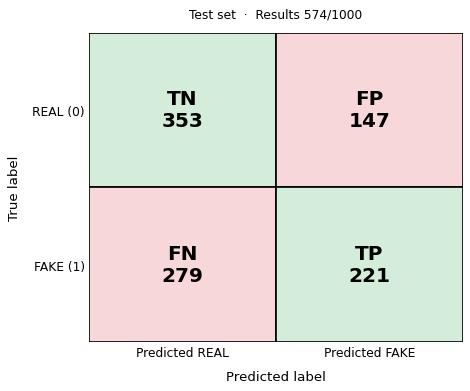

In [7]:
%matplotlib inline
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, f1_score, roc_auc_score
from IPython.display import Image, display

RESULTS_JSON = "/content/DiffusionForensics_Recons/test_inference_results.json"
THRESHOLD = 0.5  # keep same threshold as inference

with open(RESULTS_JSON, "r") as f:
    results = json.load(f)

y_true = np.array([r["true_label"] for r in results])
y_pred = np.array([r["pred"] for r in results])
y_score = np.array([r["score"] for r in results])

f1 = f1_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_score)
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

TN, FP, FN, TP = cm.ravel()

total = TP + TN + FP + FN
correct = TP + TN
wrong = FP + FN

accuracy = correct / total if total > 0 else 0.0
precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0

print(f"Test F1: {f1:.4f}")
print(f"Test AUC: {auc:.4f}")
print(f"Result: {correct}/{total}")

print(f"{'═'*44}")
print(f"  Confusion Matrix Results")
print(f"{'═'*44}")
print(f"  TP (fake correctly detected) : {TP}")
print(f"  TN (real correctly detected) : {TN}")
print(f"  FP (real wrongly called fake): {FP}")
print(f"  FN (fake wrongly called real): {FN}")
print(f"{'─'*44}")


# Styled confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor("white")

cell_labels = [["TN", "FP"], ["FN", "TP"]]
cell_values = [[TN, FP], [FN, TP]]
cell_colors = [
    ["#d4edda", "#f8d7da"],  # TN green, FP red
    ["#f8d7da", "#d4edda"]   # FN red, TP green
]

for i in range(2):
    for j in range(2):
        ax.add_patch(
            plt.Rectangle(
                (j, 1 - i), 1, 1,
                facecolor=cell_colors[i][j],
                edgecolor="black",
                linewidth=1.5
            )
        )
        ax.text(
            j + 0.5, 1 - i + 0.5,
            f"{cell_labels[i][j]}\n{cell_values[i][j]}",
            ha="center", va="center",
            fontsize=18, fontweight="bold", color="black"
        )

ax.set_xlim(0, 2)
ax.set_ylim(0, 2)
ax.set_xticks([0.5, 1.5])
ax.set_yticks([0.5, 1.5])
ax.set_xticklabels(["Predicted REAL", "Predicted FAKE"], fontsize=11)
ax.set_yticklabels(["FAKE (1)", "REAL (0)"], fontsize=11)
ax.set_xlabel("Predicted label", fontsize=12, labelpad=10)
ax.set_ylabel("True label", fontsize=12, labelpad=10)
ax.tick_params(length=0)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title(
    f"Test set  ·  Results {correct}/{total}",
    fontsize=11,
    pad=14
)

out_path = "/content/drive/MyDrive/Capstone_Hripsime/submission/results/figures/capsule_test_cm.jpg"

plt.tight_layout()
plt.savefig(out_path, dpi=80, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.close(fig)
display(Image(out_path))

PublicTest: 574/1000 correct (57.4% accuracy)
REAL images: 500  |  FAKE images: 500
Well detected: 574  |  Badly detected: 426
TP=221, TN=353, FP=147, FN=279

REAL accuracy: 70.60%
FAKE accuracy: 44.20%
FAKE precision: 0.6005
FAKE recall: 0.4420
FAKE F1: 0.5092


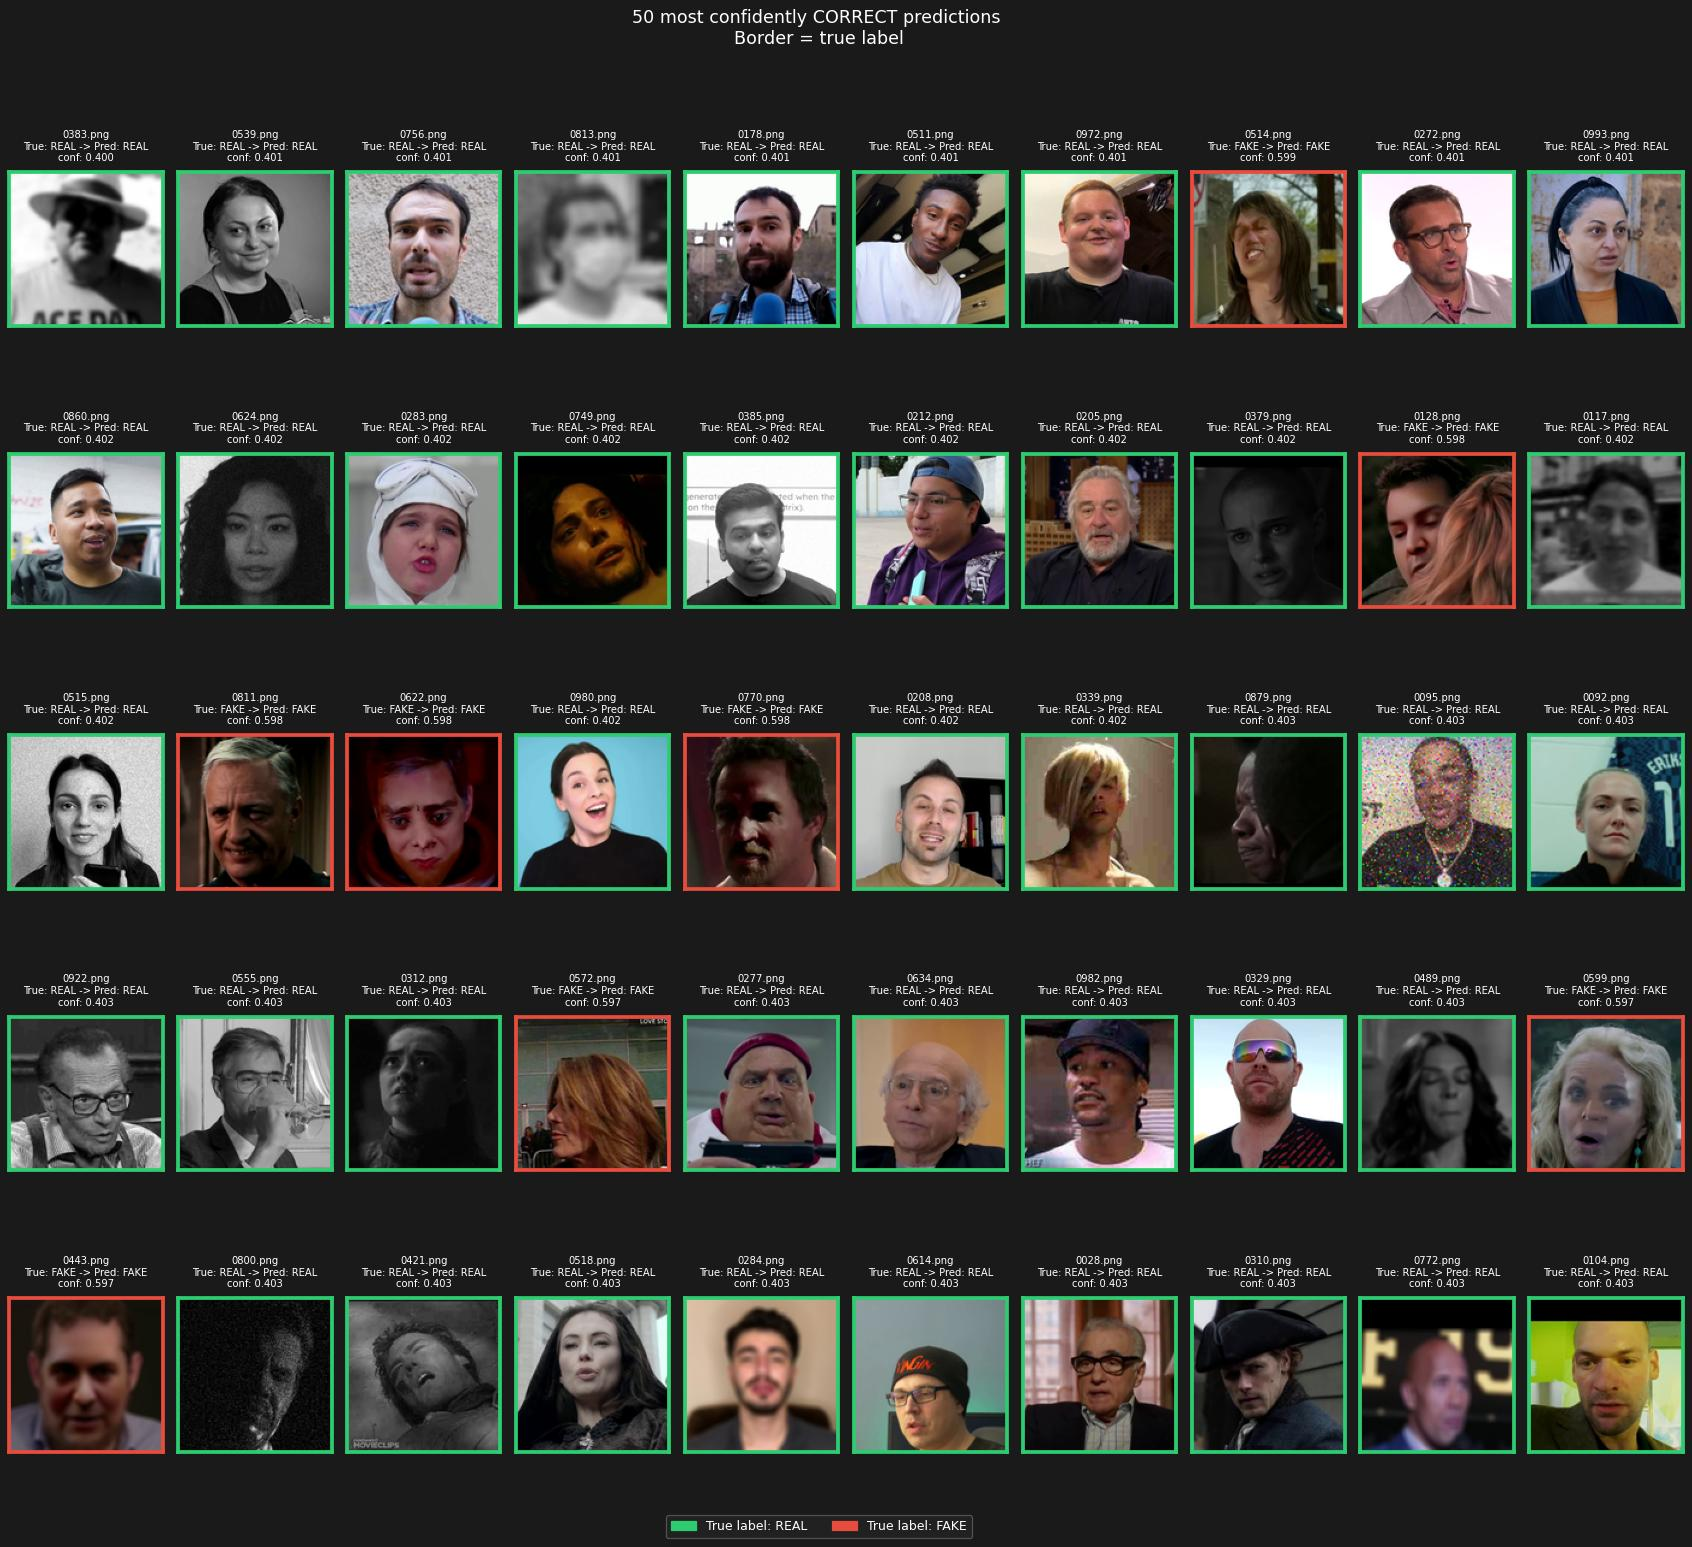

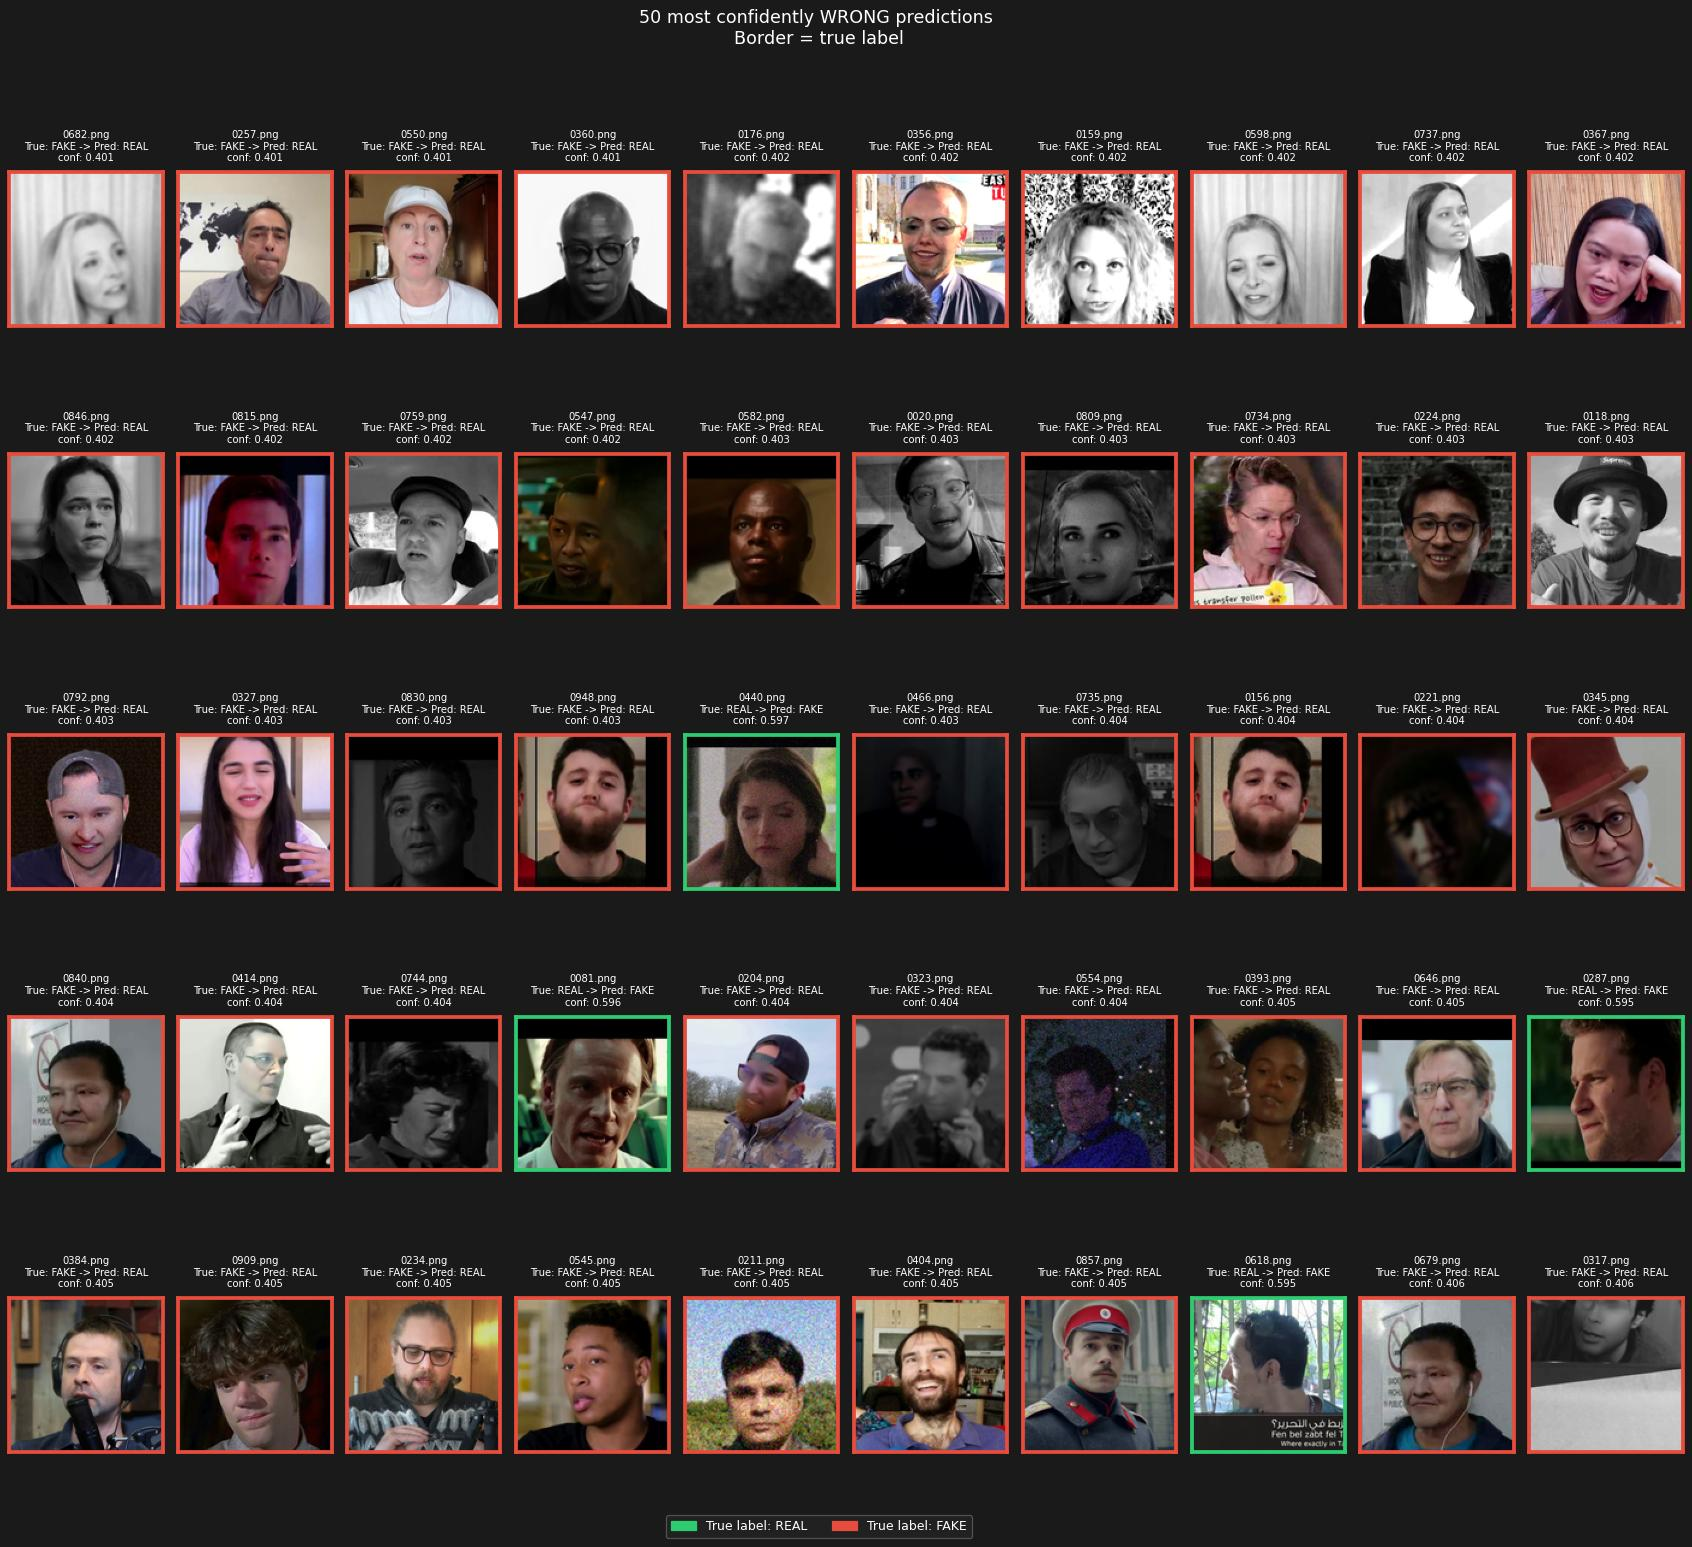

In [ ]:
# ── Badly / Well Detected — PublicTest ──

%matplotlib inline

import os
import json
from PIL import Image as PILImage
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import Image, display

# ── Load test results ─────────────────────────────────────────────────────────
RESULTS_JSON = "/content/DiffusionForensics_Recons/test_inference_results.json"

with open(RESULTS_JSON, "r") as f:
    results = json.load(f)

# ── Build correct/incorrect using "score" key from test JSON ──────────────────
for r in results:
    r["confidence"] = r["score"]
    r["correct"] = (r["pred"] == r["true_label"])

total = len(results)
n_correct = sum(r["correct"] for r in results)
accuracy = 100 * n_correct / total

well  = [r for r in results if r["correct"]]
badly = [r for r in results if not r["correct"]]

well_sorted  = sorted(well,  key=lambda x: abs(x["confidence"] - 0.5), reverse=True)
badly_sorted = sorted(badly, key=lambda x: abs(x["confidence"] - 0.5), reverse=True)

well_sample  = well_sorted[:50]
badly_sample = badly_sorted[:50]

n_real = sum(r["true_label"] == 0 for r in results)
n_fake = sum(r["true_label"] == 1 for r in results)

tp = sum((r["true_label"] == 1 and r["pred"] == 1) for r in results)
tn = sum((r["true_label"] == 0 and r["pred"] == 0) for r in results)
fp = sum((r["true_label"] == 0 and r["pred"] == 1) for r in results)
fn = sum((r["true_label"] == 1 and r["pred"] == 0) for r in results)

real_acc = 100 * tn / max(1, n_real)
fake_acc = 100 * tp / max(1, n_fake)
precision_fake = tp / max(1, tp + fp)
recall_fake = tp / max(1, tp + fn)
f1_fake = 2 * precision_fake * recall_fake / max(1e-12, precision_fake + recall_fake)

print(f"PublicTest: {n_correct}/{total} correct ({accuracy:.1f}% accuracy)")
print(f"REAL images: {n_real}  |  FAKE images: {n_fake}")
print(f"Well detected: {len(well)}  |  Badly detected: {len(badly)}")
print(f"TP={tp}, TN={tn}, FP={fp}, FN={fn}")
print(f"\nREAL accuracy: {real_acc:.2f}%")
print(f"FAKE accuracy: {fake_acc:.2f}%")
print(f"FAKE precision: {precision_fake:.4f}")
print(f"FAKE recall: {recall_fake:.4f}")
print(f"FAKE F1: {f1_fake:.4f}")

# ── Helpers ───────────────────────────────────────────────────────────────────
def label_str(l):
    return "REAL" if l == 0 else "FAKE"

def load_thumb(path, size=128):
    img = PILImage.open(path).convert("RGB")
    w, h = img.size
    side = min(w, h)
    img = img.crop(((w - side) // 2, (h - side) // 2,
                    (w + side) // 2, (h + side) // 2))
    return img.resize((size, size), PILImage.LANCZOS)

def make_grid(samples, title, filename):
    n = len(samples)
    cols = 10
    rows = max(1, (n + cols - 1) // cols)

    fig, axes = plt.subplots(rows, cols, figsize=(24, rows * 3.5))
    fig.patch.set_facecolor('#1a1a1a')

    if rows == 1:
        axes = [axes]

    for idx, ax in enumerate([a for row in axes for a in row]):
        if idx >= n:
            ax.axis('off')
            continue

        r = samples[idx]
        try:
            ax.imshow(load_thumb(r["path"]))
        except Exception:
            ax.set_facecolor('#333')
            ax.text(0.5, 0.5, 'error', ha='center', va='center',
                    color='white', fontsize=7, transform=ax.transAxes)

        true_color = '#2ecc71' if r["true_label"] == 0 else '#e74c3c'
        for spine in ax.spines.values():
            spine.set_edgecolor(true_color)
            spine.set_linewidth(3)

        ax.set_xticks([]); ax.set_yticks([])

        fname = os.path.basename(r["path"])
        ax.set_title(
            f"{fname}\nTrue: {label_str(r['true_label'])} -> Pred: {label_str(r['pred'])}\n"
            f"conf: {r['confidence']:.3f}",
            fontsize=8, color='white', pad=9
        )

    real_p = mpatches.Patch(color='#2ecc71', label='True label: REAL')
    fake_p = mpatches.Patch(color='#e74c3c', label='True label: FAKE')
    fig.legend(handles=[real_p, fake_p], loc='lower center', ncol=2,
               fontsize=10, framealpha=0.3, facecolor='#333',
               labelcolor='white', bbox_to_anchor=(0.5, 0.005))

    fig.suptitle(title, fontsize=14, color='white', fontweight='medium')
    plt.subplots_adjust(hspace=0.7, wspace=0.1, top=0.88, bottom=0.06)

    plt.savefig(filename, dpi=90, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.close(fig)
    display(Image(filename))



# ── Plots ─────────────────────────────────────────────────────────────────────
make_grid(
    well_sample,
    title=f'50 most confidently CORRECT predictions \n'
          'Border = true label',
    filename='well_detected_test.jpg'
)

make_grid(
    badly_sample,
    title=f'50 most confidently WRONG predictions \n'
          'Border = true label',
    filename='badly_detected_test.jpg'
)


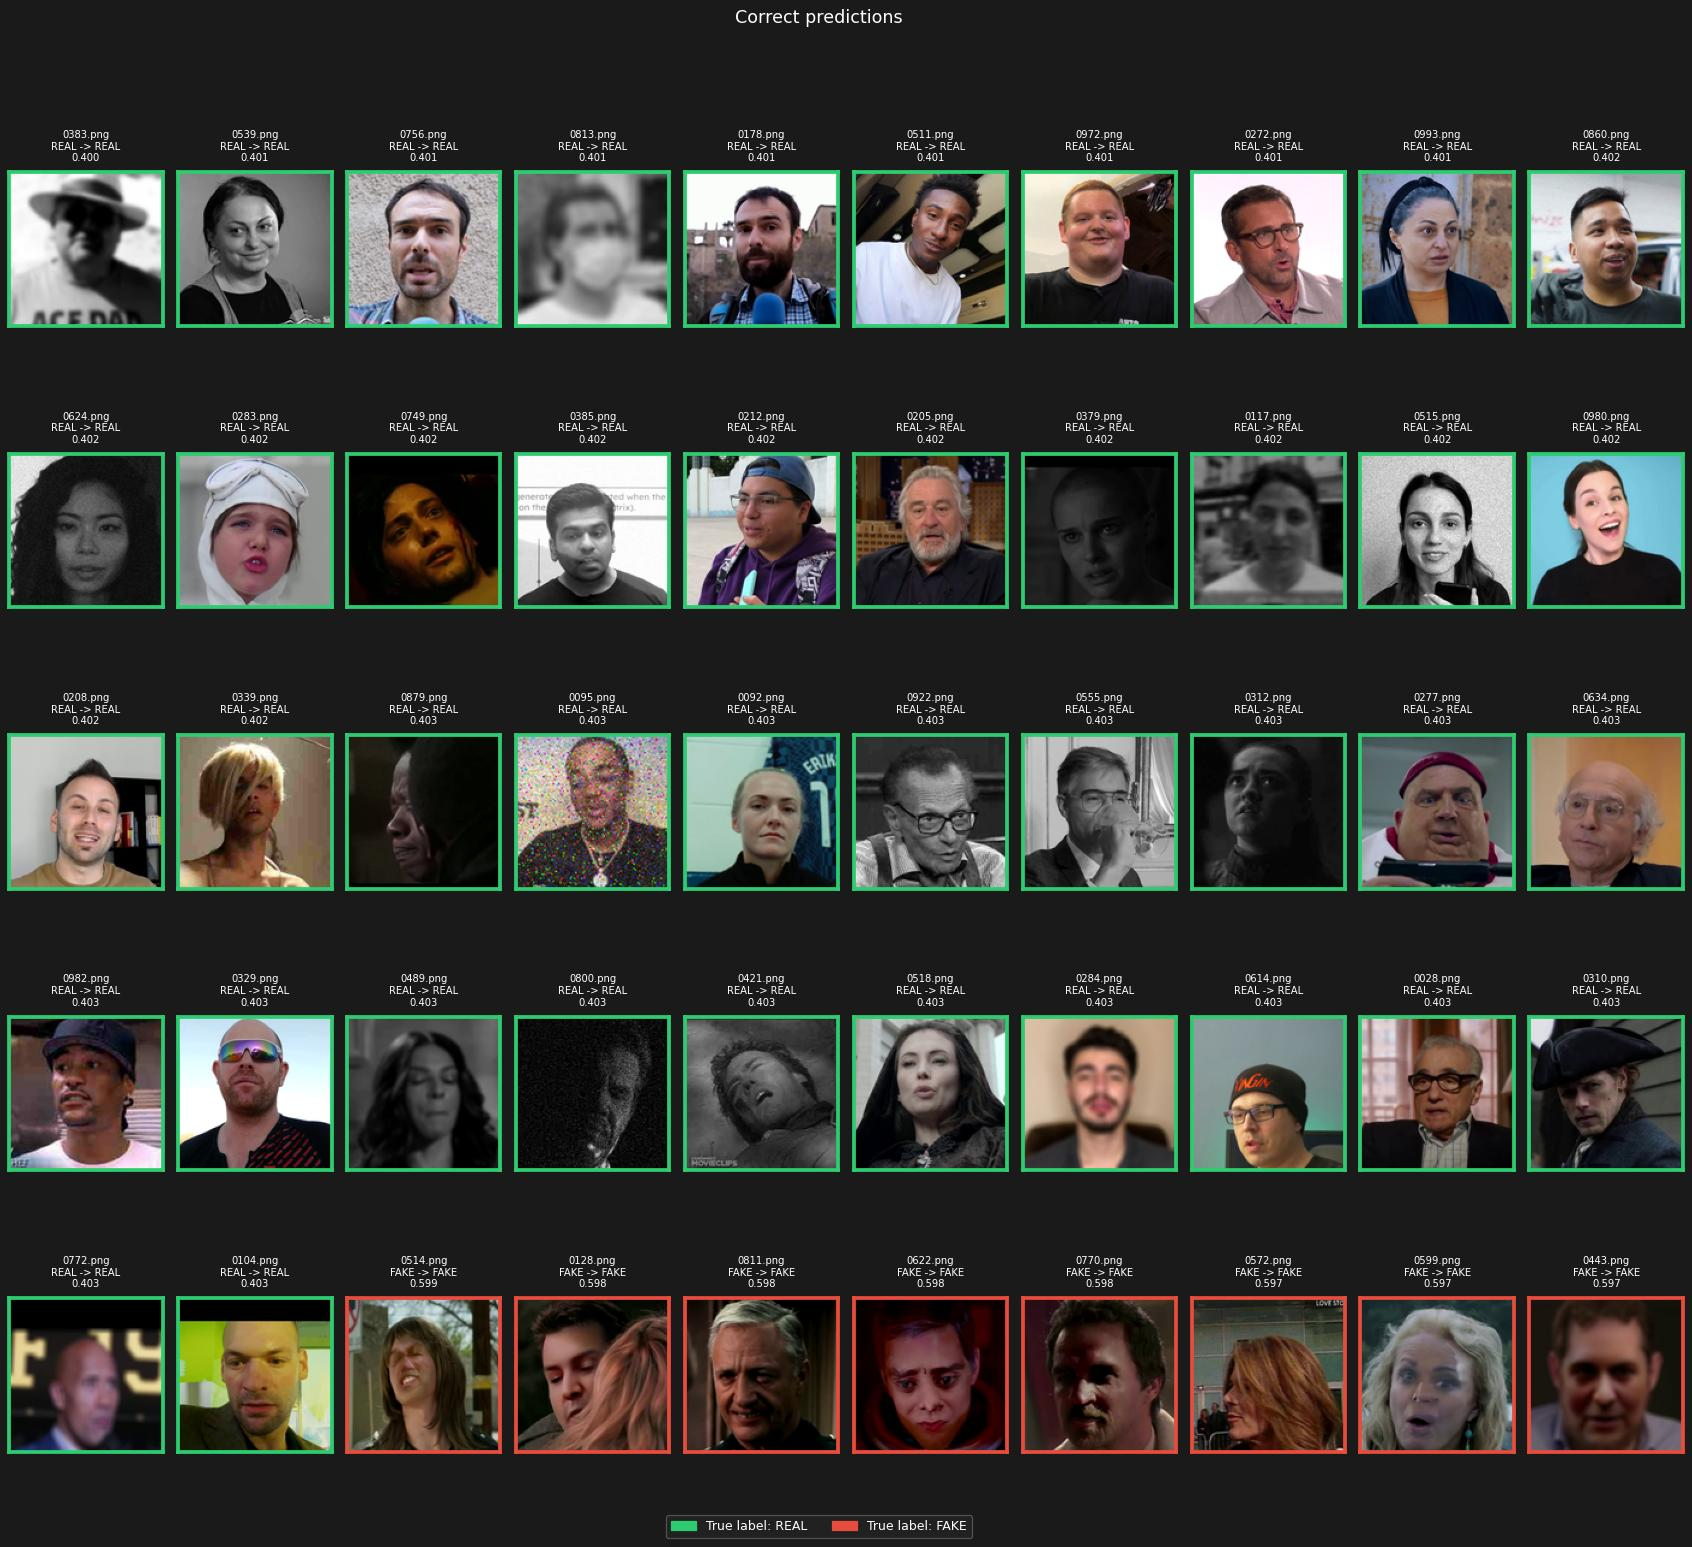

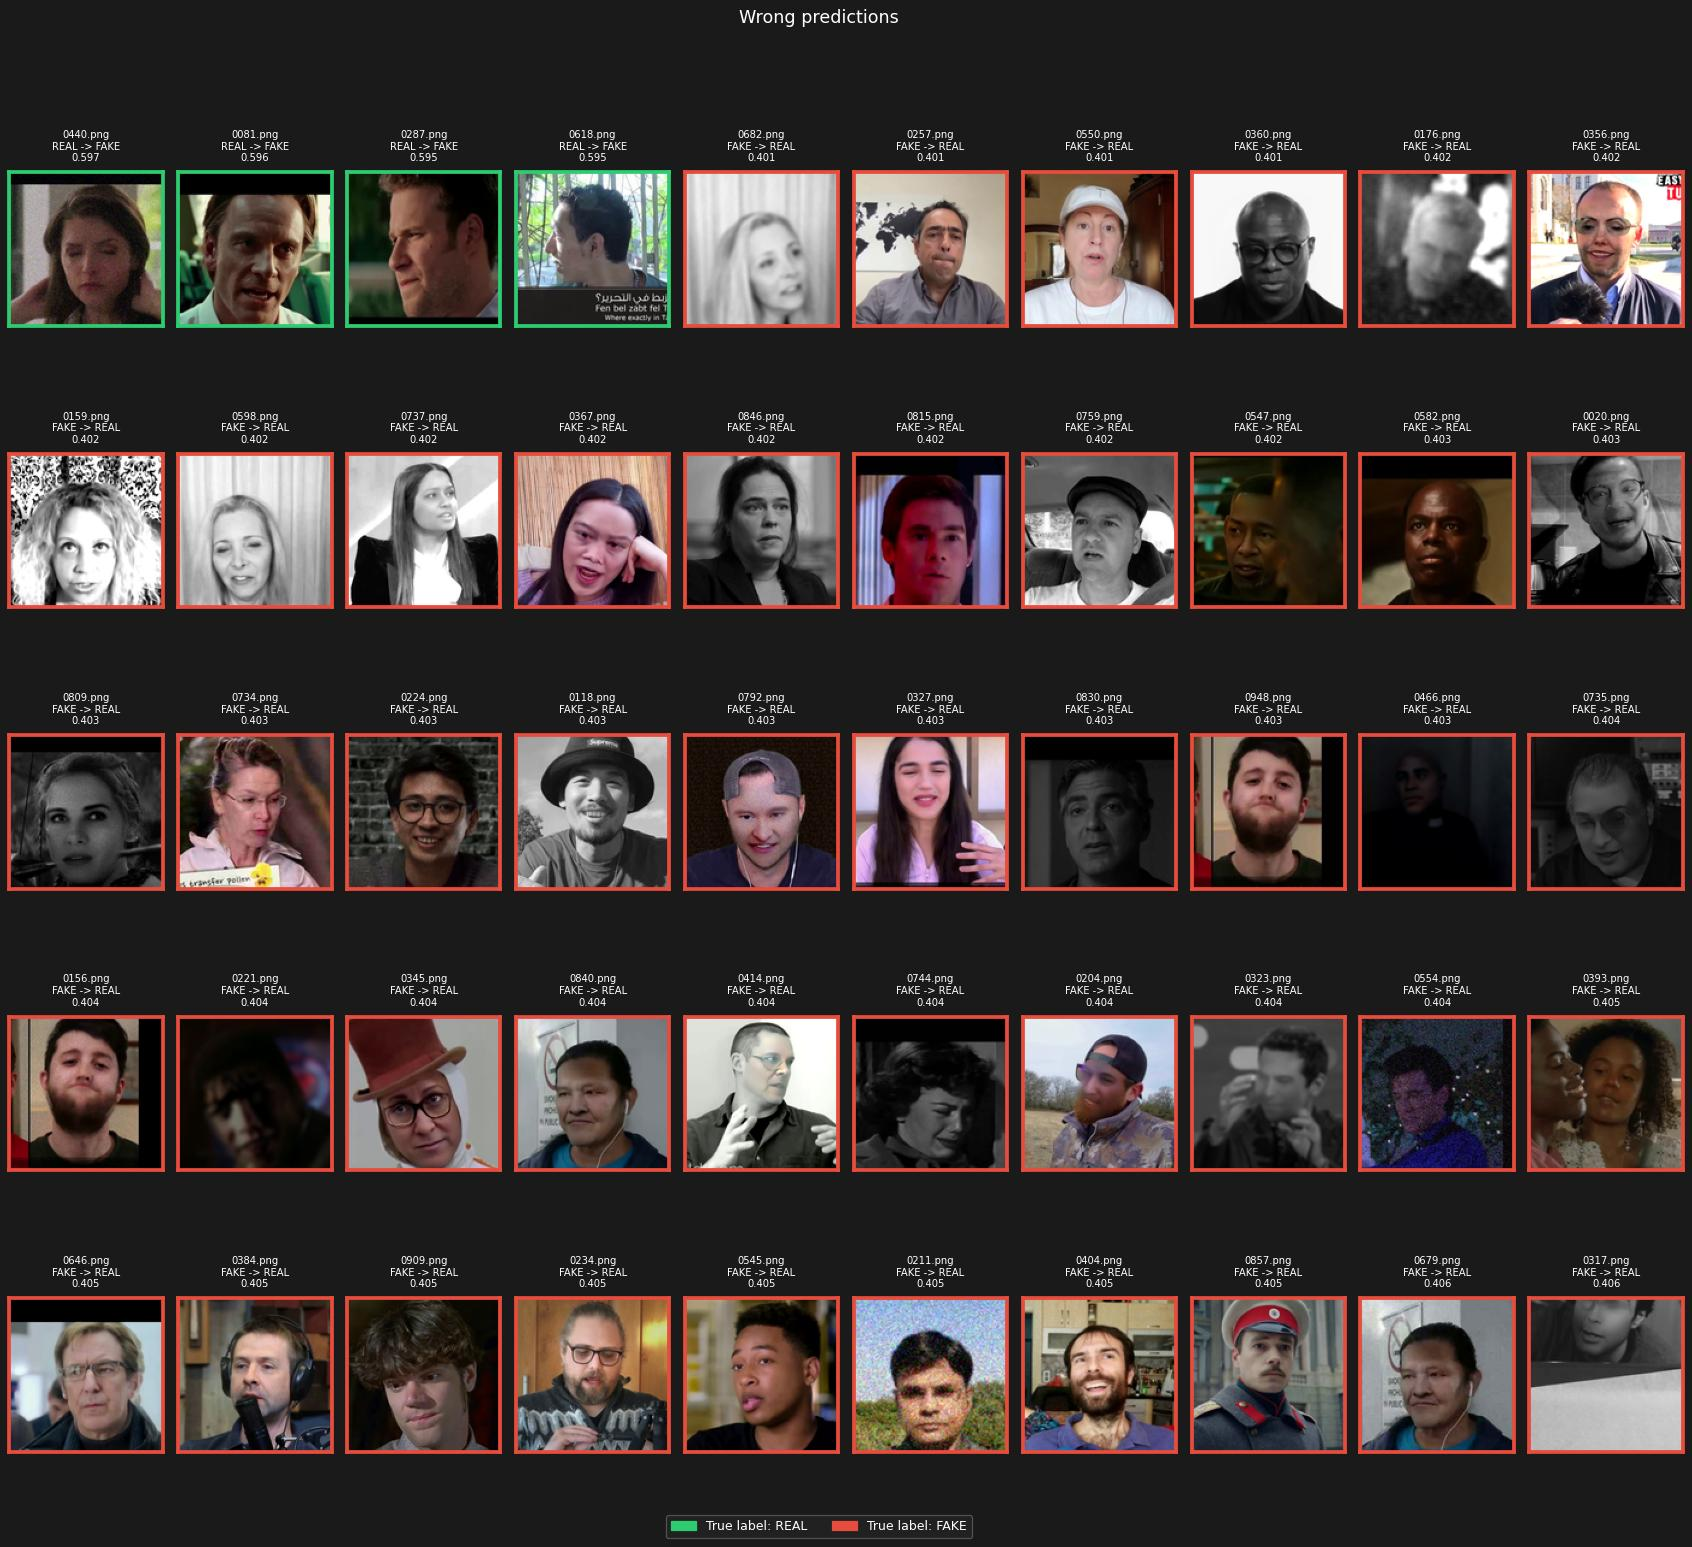

In [ ]:
# ── Badly / Well Detected — top 50 by confidence, then grouped REAL / FAKE ──

%matplotlib inline

import os
import json
from PIL import Image as PILImage
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import Image, display

RESULTS_JSON = "/content/DiffusionForensics_Recons/test_inference_results.json"

with open(RESULTS_JSON, "r") as f:
    results = json.load(f)

if len(results) == 0:
    raise RuntimeError("Test results file is empty.")

for r in results:
    if "confidence" not in r:
        r["confidence"] = r["score"]
    if "correct" not in r:
        r["correct"] = (r["pred"] == r["true_label"])

well  = [r for r in results if r["correct"]]
badly = [r for r in results if not r["correct"]]

# 1) sort by confidence distance from 0.5
well_sorted  = sorted(well,  key=lambda x: abs(x["confidence"] - 0.5), reverse=True)
badly_sorted = sorted(badly, key=lambda x: abs(x["confidence"] - 0.5), reverse=True)

# 2) take top 50 first
well_top50  = well_sorted[:50]
badly_top50 = badly_sorted[:50]

# 3) then group REAL first, FAKE second, preserving the order inside each label
def group_real_fake(samples):
    real_group = [r for r in samples if r["true_label"] == 0]
    fake_group = [r for r in samples if r["true_label"] == 1]
    return real_group + fake_group

well_sample  = group_real_fake(well_top50)
badly_sample = group_real_fake(badly_top50)

def label_str(l):
    return "REAL" if l == 0 else "FAKE"

def load_thumb(path, size=128):
    img = PILImage.open(path).convert("RGB")
    w, h = img.size
    side = min(w, h)
    img = img.crop(((w - side) // 2, (h - side) // 2,
                    (w + side) // 2, (h + side) // 2))
    return img.resize((size, size), PILImage.LANCZOS)

def make_grid(samples, title, filename, cols=10):
    n = len(samples)
    if n == 0:
        print(f"No samples to show for {filename}")
        return

    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(24, rows * 3.5))
    fig.patch.set_facecolor('#1a1a1a')

    if rows == 1:
        axes = [axes]
    flat_axes = [a for row in axes for a in row]

    for idx, ax in enumerate(flat_axes):
        if idx >= n:
            ax.axis('off')
            continue

        r = samples[idx]
        try:
            ax.imshow(load_thumb(r["path"]))
        except Exception:
            ax.set_facecolor('#333')
            ax.text(0.5, 0.5, 'error', ha='center', va='center',
                    color='white', fontsize=7, transform=ax.transAxes)

        true_color = '#2ecc71' if r["true_label"] == 0 else '#e74c3c'
        for spine in ax.spines.values():
            spine.set_edgecolor(true_color)
            spine.set_linewidth(3)

        ax.set_xticks([])
        ax.set_yticks([])

        fname = os.path.basename(r["path"])
        ax.set_title(
            f"{fname}\n{label_str(r['true_label'])} -> {label_str(r['pred'])}\n"
            f"{r['confidence']:.3f}",
            fontsize=8, color='white', pad=9
        )

    real_p = mpatches.Patch(color='#2ecc71', label='True label: REAL')
    fake_p = mpatches.Patch(color='#e74c3c', label='True label: FAKE')
    fig.legend(handles=[real_p, fake_p], loc='lower center', ncol=2,
               fontsize=10, framealpha=0.3, facecolor='#333',
               labelcolor='white', bbox_to_anchor=(0.5, 0.005))

    fig.suptitle(title, fontsize=14, color='white', fontweight='medium')
    plt.subplots_adjust(hspace=0.7, wspace=0.1, top=0.88, bottom=0.06)

    plt.savefig(filename, dpi=90, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.close(fig)
    display(Image(filename))

make_grid(
    well_sample,
    title="Correct predictions",
    filename="well_detected_grouped.jpg"
)

make_grid(
    badly_sample,
    title="Wrong predictions",
    filename="badly_detected_grouped.jpg"
)

In [9]:
# Step 1 — install nbconvert (already available in Colab but just in case)
!pip install nbconvert -q

NOTEBOOK_PATH = "/content/drive/MyDrive/Capstone_Hripsime/Code Notebooks/CapsuleNet Test.ipynb"
OUTPUT_DIR    = "/content/drive/MyDrive/Capstone_Hripsime/Code Notebooks/HTML Notebooks"

!jupyter nbconvert \
    --to html \
    --embed-images \
    --output-dir "{OUTPUT_DIR}" \
    "{NOTEBOOK_PATH}"

print("Done — check your Drive for the .html file")

[NbConvertApp] Converting notebook /content/drive/MyDrive/Capstone_Hripsime/Code Notebooks/CapsuleNet Test.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 5 image(s).
[NbConvertApp] Writing 2258913 bytes to /content/drive/MyDrive/Capstone_Hripsime/Code Notebooks/HTML Notebooks/CapsuleNet Test.html
Done — check your Drive for the .html file
